In [7]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import gzip 
import re
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import Rectangle
import edlib
from matplotlib.collections import BrokenBarHCollection
import os 

In [9]:


import zlib
from matplotlib import cm, colors

DNA_COMP = str.maketrans("ACGTacgtnN", "TGCAtgcaNn")
def rc(s): 
    return s.translate(DNA_COMP)[::-1]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    base = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
    return colors.ListedColormap(base(np.linspace(minval, maxval, n)))

class HashKmerColorManager:
    def __init__(self, k=6, canonical="CCCTAA",
                 cmap="cubehelix_r", cmap_min=0.15, cmap_max=0.95,
                 tie_rc=False, pin_canonical=True):
        self.k = k
        self.canonical = canonical.upper()
        self.cmap = truncate_colormap(cmap, cmap_min, cmap_max)
        self.tie_rc = tie_rc
        self.pin_canonical = pin_canonical
        self.cache_hex = {}
        self.cache_rgba = {}
        self.gray_hex = "#bfbfbf"
        self.gray_rgba = (0.75, 0.75, 0.75, 1.0)

    def _key(self, kmer: str) -> str:
        kmer = kmer.upper()
        if self.tie_rc:
            rcmer = rc(kmer)
            return kmer if kmer <= rcmer else rcmer
        return kmer

    def _scalar(self, key: str) -> float:
        """CRC32 hash -> [0,1) scalar."""
        h = zlib.crc32(key.encode("utf-8")) & 0xffffffff
        return (h / 0xffffffff)  # normalized float 0–1

    def _is_canonical_fragment(self, kmer: str) -> bool:
        return len(kmer) > 0 and kmer.upper() == self.canonical[:len(kmer)]

    def color_hex(self, kmer: str) -> str:
        key = self._key(kmer)
        if key in self.cache_hex:
            return self.cache_hex[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_hex[key] = self.gray_hex
            return self.gray_hex

        s = self._scalar(key)
        rgba = self.cmap(s)
        rgb = tuple(int(255 * c) for c in rgba[:3])
        hexcol = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        self.cache_hex[key] = hexcol
        return hexcol

    def color_rgba(self, kmer: str):
        key = self._key(kmer)
        if key in self.cache_rgba:
            return self.cache_rgba[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_rgba[key] = self.gray_rgba
            return self.gray_rgba

        s = self._scalar(key)
        rgba = self.cmap(s)
        self.cache_rgba[key] = rgba
        return rgba

k=6
cmgr = HashKmerColorManager(
    k=k,
    canonical="TTAGGG",
    cmap="turbo",   
    cmap_min=0.05,     # skip pale start
    cmap_max=0.95,    # skip darkest end
    tie_rc=True,
    pin_canonical=False
)



def get_label_from_series(series: pd.Series) -> str:
    """
    Split first non-null value in series by '#' and combine
    first two parts with '_', e.g. 'HG01346#2#JBHDSS...' → 'HG01346_2'.
    """
    if series.empty or series.isna().all():
        return "unknown"
    first_val = series.dropna().iloc[0]
    parts = str(first_val).split("#")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return parts[0]
        
    
    
chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

# build id -> chrom mapping from chrom_alias
id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

def read_in_tsv(file,id_to_chr):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

       # map sample contig IDs to base chromosome names (e.g., "chr1")
    sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

    # if centering_position > 100kb → 'q', else 'p'
    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )

    # optional: drop helper column
    sample_tsv.drop(columns=['chr_base'], inplace=True)

    return sample_tsv

def rotations(s: str):
    return [s[i:] + s[:i] for i in range(len(s))]



def ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(s):
    plus6  = rotations("CCCTAA")   # cyclic perms (plus)
    minus6 = rotations("TTAGGG")   # cyclic perms (minus)

    pat_plus6  = re.compile(r"(?=(?:%s))" % "|".join(plus6),  re.I)
    pat_minus6 = re.compile(r"(?=(?:%s))" % "|".join(minus6), re.I)

    plus_idx  = np.fromiter((m.start() for m in pat_plus6.finditer(s)),  dtype=int)
    minus_idx = np.fromiter((m.start() for m in pat_minus6.finditer(s)), dtype=int)

    is_plus  = (plus_idx.size >= minus_idx.size)
    true_idx = plus_idx if is_plus else minus_idx
    
    if true_idx.size == 0:
        return np.empty((0, 2), dtype=int)

    L = len(s)

    canon = "CCCTAA" if is_plus else "TTAGGG"
    pat_canon = re.compile(rf"(?={canon})", re.I)
    canon_idx = np.fromiter((m.start() for m in pat_canon.finditer(s)), dtype=int)

    diff = np.zeros(L + 1, dtype=np.int16)
    if canon_idx.size > 0:
        np.add.at(diff, canon_idx, 1)
        np.add.at(diff, canon_idx + 6, -1)
        
    canon_mask = np.cumsum(diff)[:L] > 0

    low = ~canon_mask  # Invert the mask: True where it is a variant/disruption
    d = np.diff(np.pad(low.astype(np.int8), (1, 1)))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    
    # Return as [start, length] pairs
    spans  = np.column_stack([starts, ends - starts]).astype(int)
    
    return spans
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 100, 
              maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr

        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv



def sort_by_max_TVR_start(all_tsvs, chrom, dist_bp=300):
    
    
    all_max_tvr_starts = []
    
    for tsv in all_tsvs:

        tmp = tsv[tsv.chrom_assignment == chrom]

        tvr_starts = []
        for arr in tmp.get("tvr", []):
            if isinstance(arr, np.ndarray) and arr.size:
                # filter by: start > 6 and size < dist_bp
                valid = arr[(arr[:, 0] < dist_bp) & (arr[:, 1] >= 30)]
                if valid.size:
                    tvr_starts.append(valid[:, 0].max())

        max_start = np.nanmedian(tvr_starts) if tvr_starts else np.nan
        all_max_tvr_starts.append(max_start)

    sort_order = np.argsort(np.nan_to_num(all_max_tvr_starts, nan=np.inf))
    return sort_order

        
canonical_arms = [
    f"chr{i}{arm}" for i in range(1, 23) for arm in ("p", "q")
] + ["chrXp", "chrXq", "chrYp", "chrYq"]
        

In [10]:
def plotTVRs_three_samples_one_chrom(
    pedigree_tsvs,
    chrom_end,
    dist_bp=5_000,
    figsize=(3, 6),          
    spacing_between_mols=2,
    cmgr=None,
    min_tvr_size=6,
    max_tvr_size=300,
    k=6,
    out_name=None,
    min_reads=3,
    samples=("HG002", "HG003", "HG004"),
    labels=("HG002", "Paternal (HG003)", "Maternal (HG004)"),
):
    assert cmgr is not None, "Pass cmgr with cmgr.color_rgba(kmer)."

    fig, axes = plt.subplots(
        3, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(hspace=0.25)
    )
    canonical_gray = "whitesmoke"

    def _draw_one(ax, ont_df, panel_label):
        y_offset = 0

        df = ont_df[ont_df.chrom_assignment == chrom_end]

        ax.text(
            0, y_offset + 1.5,
            f"{panel_label} (n={len(df)})",
            ha="left", va="bottom", fontsize=8
        )
        y_offset += 4

        if len(df) < min_reads:
            ax.set_xlim(0, dist_bp)
            ax.set_ylim(0, 10)
            ax.set_yticks([])
            ax.tick_params(axis='y', left=False, labelleft=False)
            ax.tick_params(axis='x', bottom=True, labelbottom=False)
            return

        if "centered_query_end" in df.columns:
            df_sorted = df.sort_values("centered_query_end")
        else:
            df_sorted = df.assign(_span=df["teloseq"].astype(str).str.len()).sort_values("_span")

        for row in df_sorted.itertuples(index=False):
            qe = getattr(row, "centered_query_end", dist_bp)
            try:
                qe = int(qe)
            except Exception:
                qe = dist_bp

            teloseq = getattr(row, "teloseq", "")
            tvr = getattr(row, "tvr", None)

            if not isinstance(teloseq, str) or len(teloseq) == 0:
                continue
            if tvr is None:
                y_offset += spacing_between_mols
                continue

            L = min(qe, dist_bp, len(teloseq))
            if L <= 0:
                y_offset += spacing_between_mols
                continue

            tvr_arr = np.asarray(tvr)
            if tvr_arr.size == 0:
                y_offset += spacing_between_mols
                continue
            if tvr_arr.ndim != 2 or tvr_arr.shape[1] < 2:
                y_offset += spacing_between_mols
                continue

            segments_by_color = {}

            for start, length in zip(tvr_arr[:, 0], tvr_arr[:, 1]):
                start = int(start)
                length = int(length)

                if length < min_tvr_size or length > max_tvr_size:
                    continue
                if start >= dist_bp or start >= L:
                    continue

                end = min(start + length, L)
                pos = start

                while pos < end:
                    frag_end = min(pos + k, end)
                    frag = teloseq[pos:frag_end]
                    if not frag:
                        break

                    color = cmgr.color_rgba(frag)

                    run_end = frag_end
                    stride = frag_end - pos
                    while run_end + stride <= end and teloseq[run_end:run_end + stride] == frag:
                        run_end += stride

                    segments_by_color.setdefault(color, []).append((pos, run_end - pos))
                    pos = run_end

            if not segments_by_color:
                y_offset += spacing_between_mols
                continue

            ax.add_patch(Rectangle(
                (0, y_offset - 0.4), L, 0.8,
                color=canonical_gray, lw=0, antialiased=False, alpha=1
            ))

            for color, spans in segments_by_color.items():
                coll = BrokenBarHCollection(
                    xranges=spans,
                    yrange=(y_offset - 0.4, 0.8),
                    facecolors=[color],
                    edgecolors=[color],
                    linewidths=0.1,
                    antialiased=False,
                )
                ax.add_collection(coll)

            y_offset += spacing_between_mols

        ax.set_xlim(0, dist_bp)
        ax.set_ylim(-2, y_offset + 10)
        ax.set_yticks([])
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.set_rasterization_zorder(1)
        ax.tick_params(axis='x', bottom=True, labelbottom=False)

    for ax, sample, lab in zip(axes, samples, labels):
        _draw_one(ax, pedigree_tsvs[sample], lab)

    axes[-1].tick_params(axis='x', bottom=True, labelbottom=True)
    axes[-1].set_xlabel("Distance from subtelomere boundary (bp)")

    plt.suptitle(f"{chrom_end}", fontsize=9, y=0.995)

    plt.tight_layout()
    if out_name is not None:
        plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
def read_in_pedigree_tsv(file):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chrom'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )


    return sample_tsv


pedigree_tsvs = {} 

for file in tqdm(glob("data_for_submission/pedigree/HG*center.txt.gz")) : 
    individual = file.split('/')[-1].split('.')[0]
    pedigree_tsvs[individual] = assignTVRAndAddTelomereSequenceColumn(read_in_pedigree_tsv(file))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.09s/it]


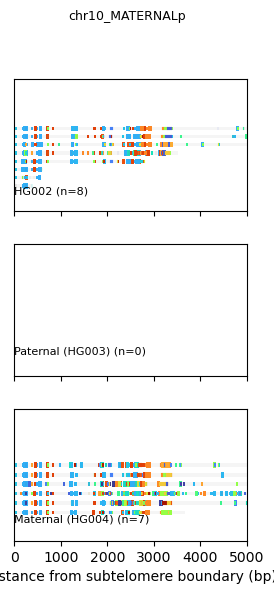

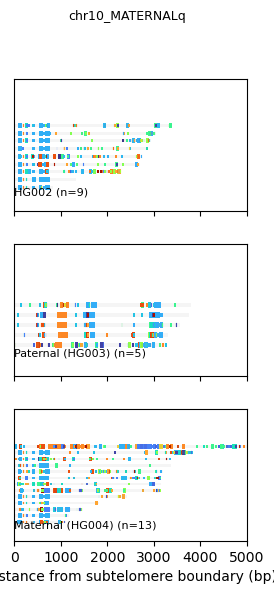

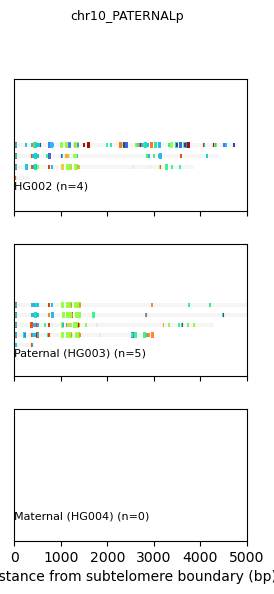

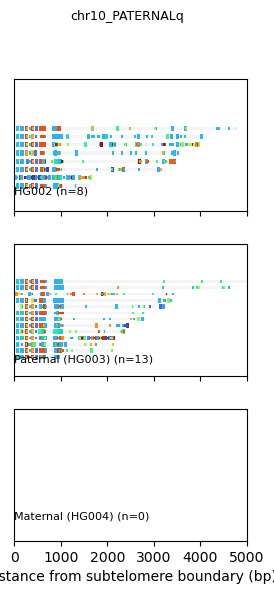

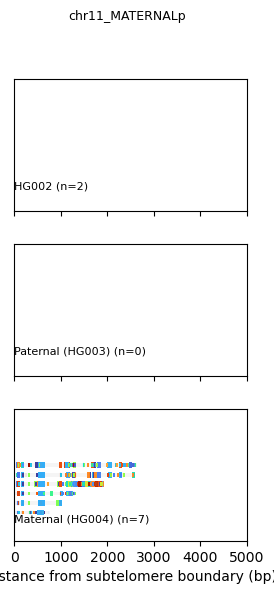

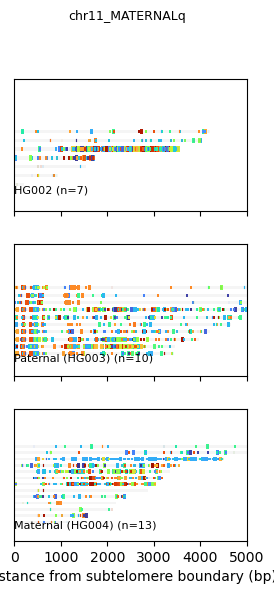

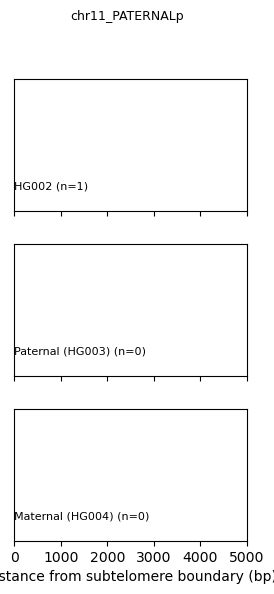

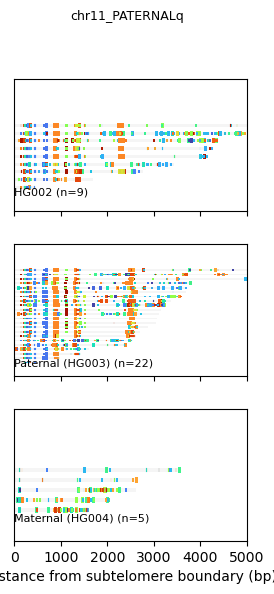

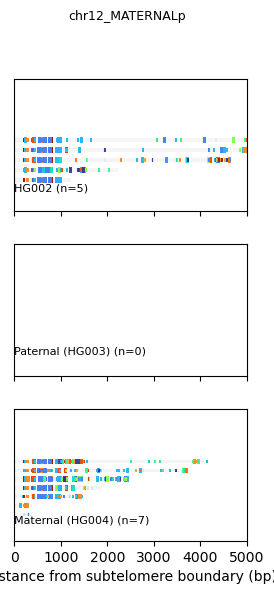

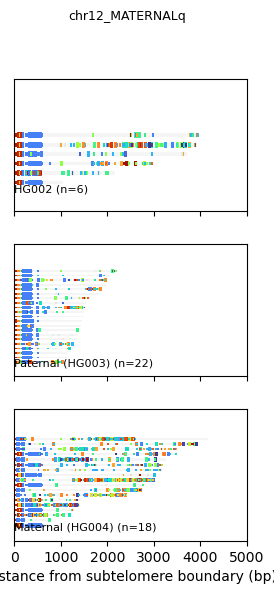

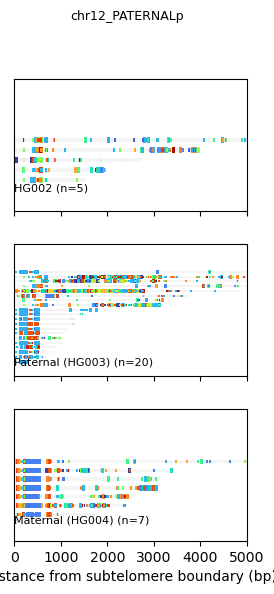

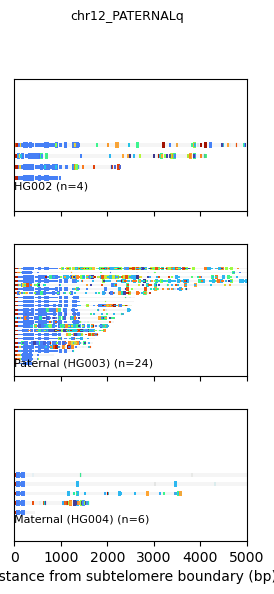

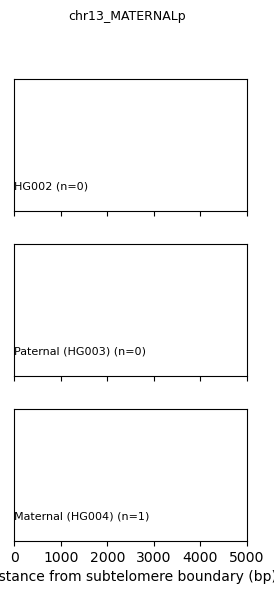

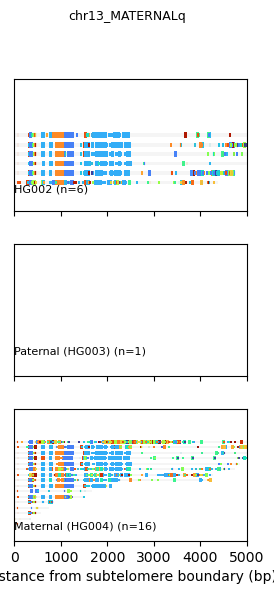

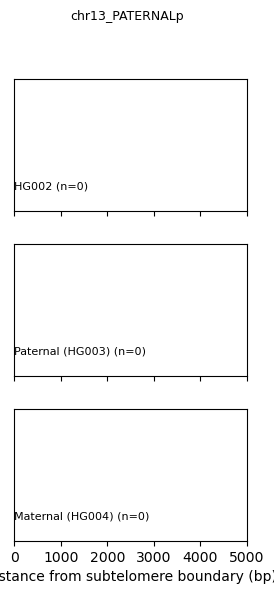

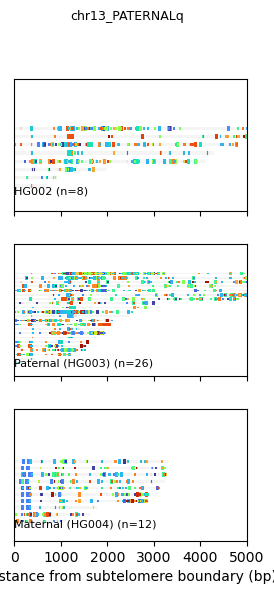

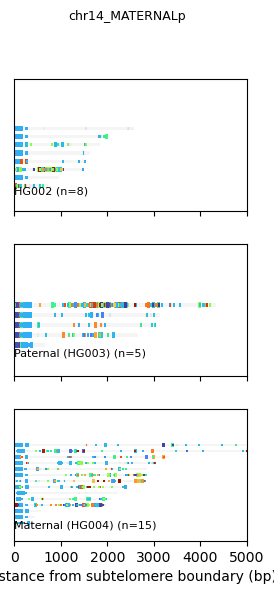

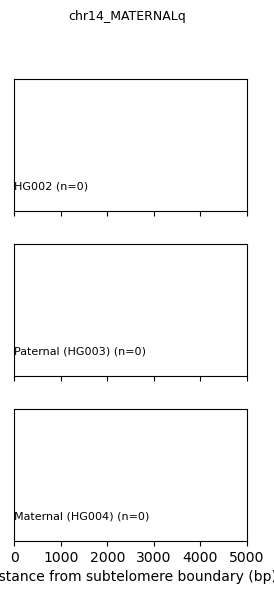

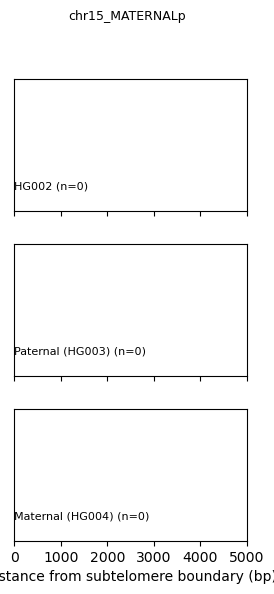

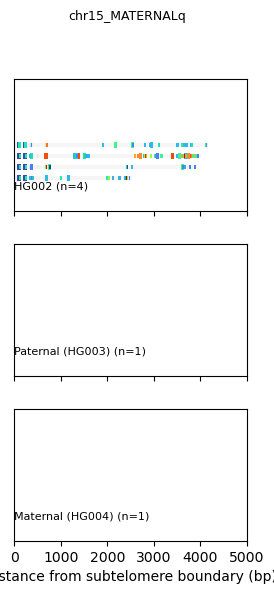

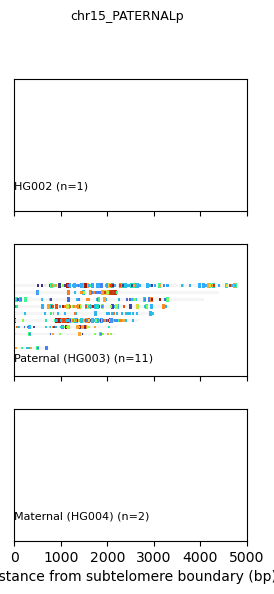

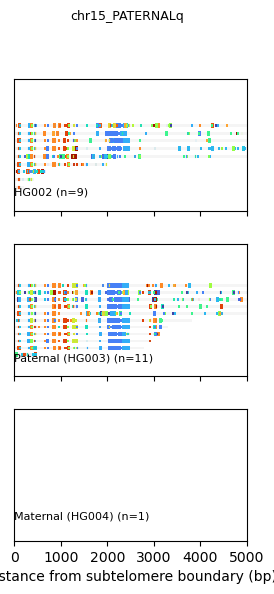

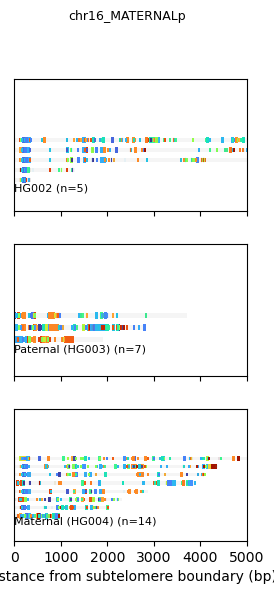

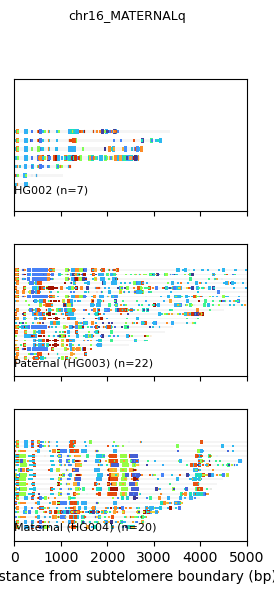

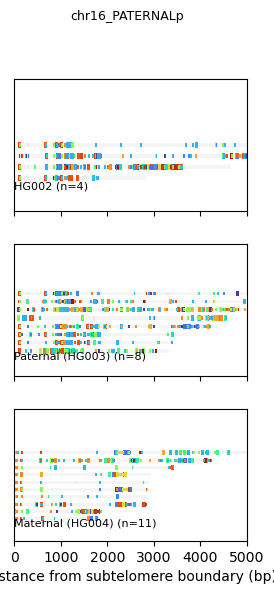

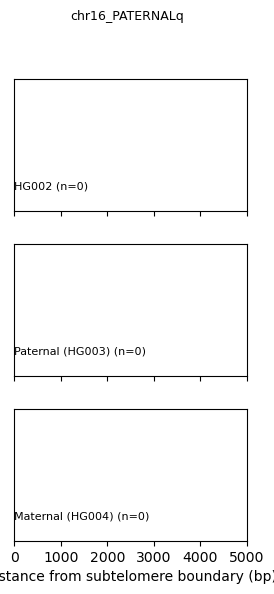

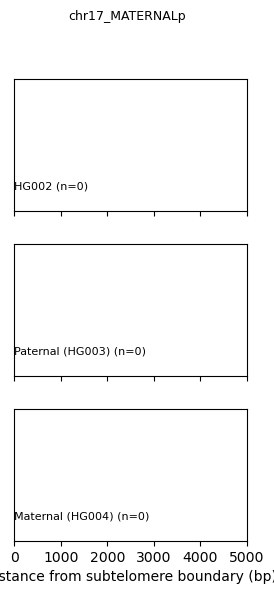

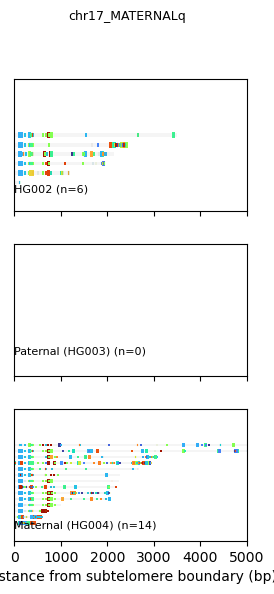

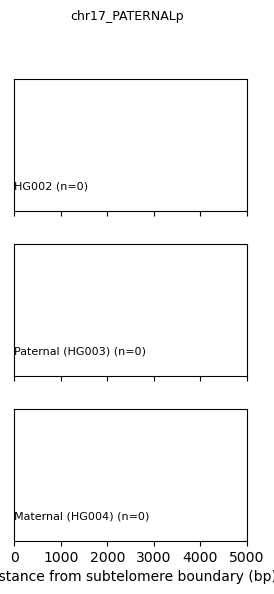

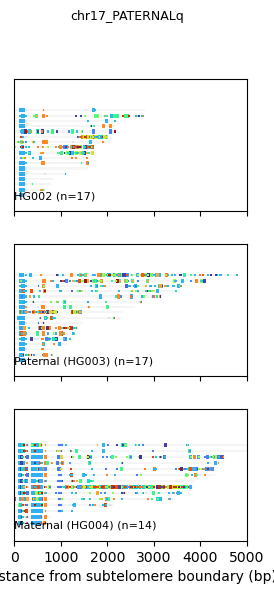

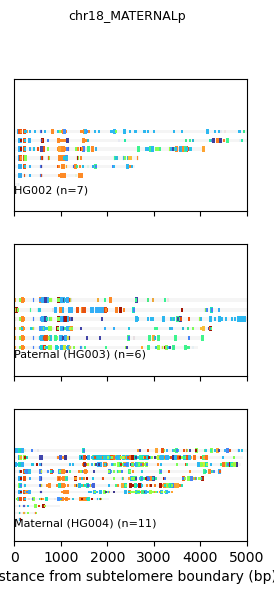

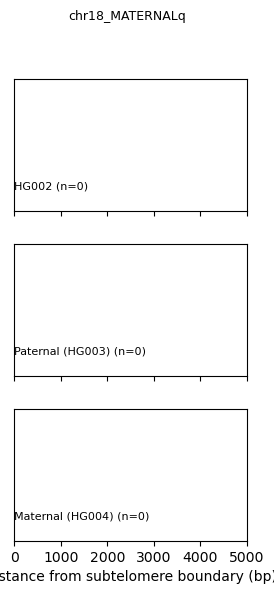

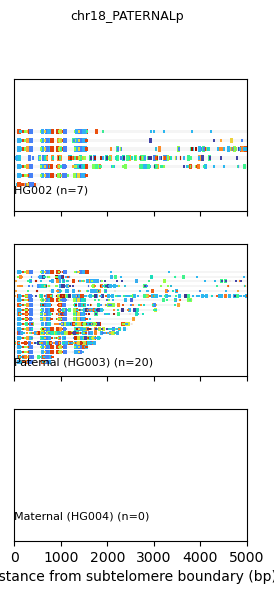

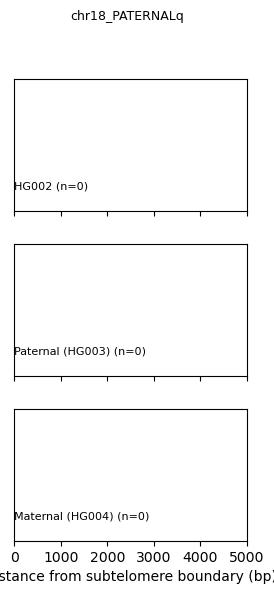

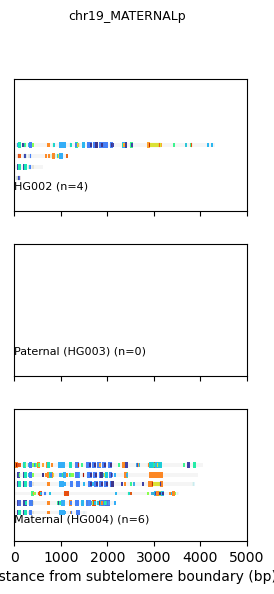

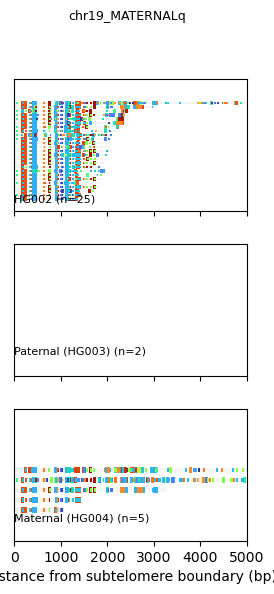

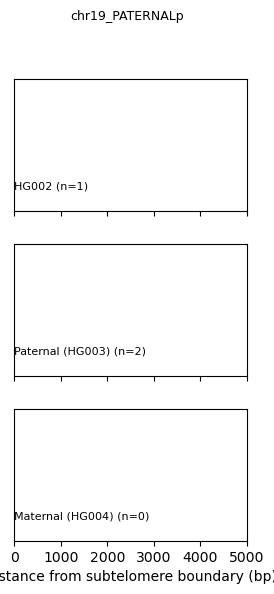

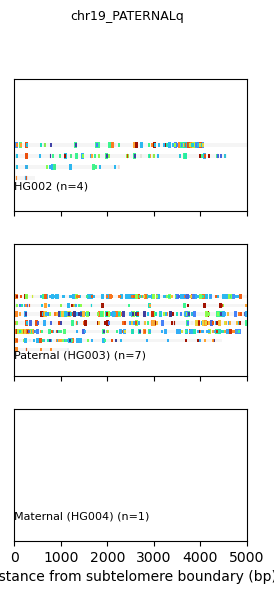

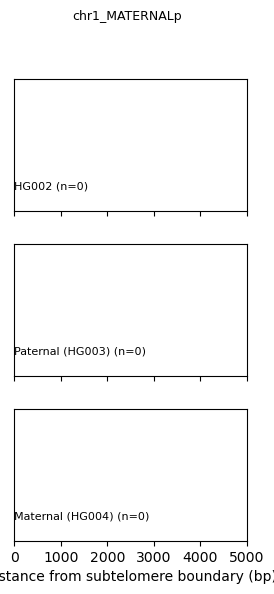

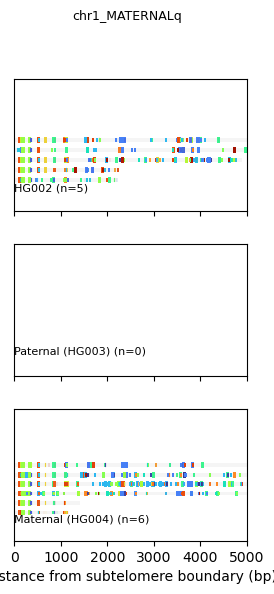

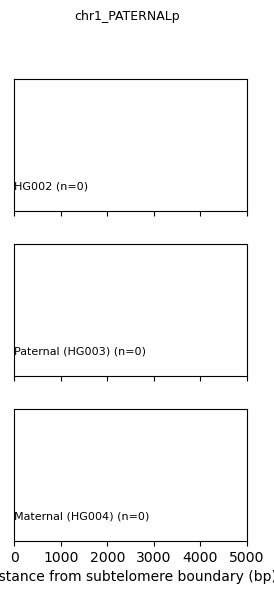

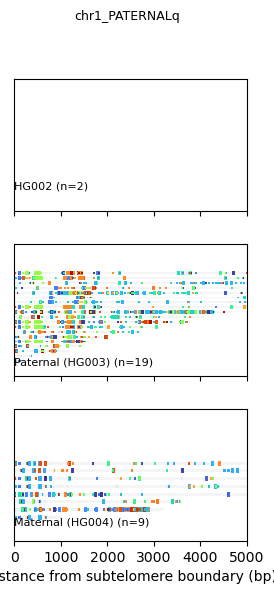

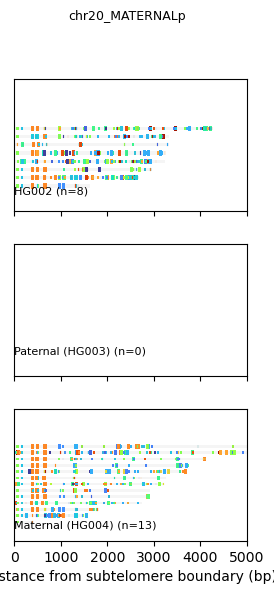

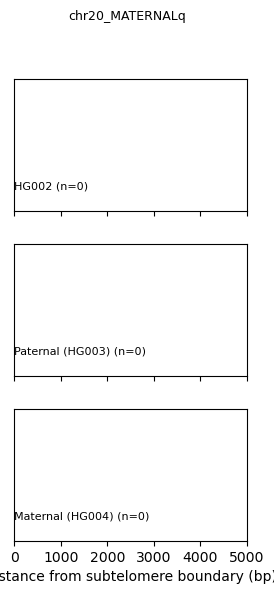

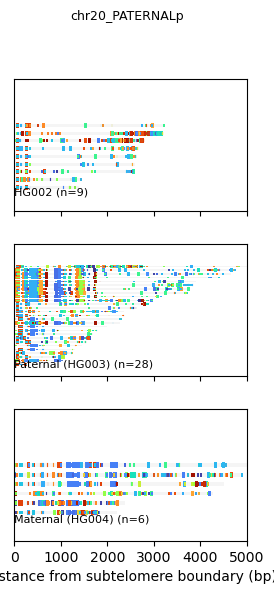

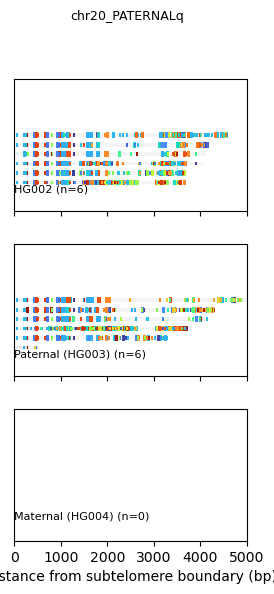

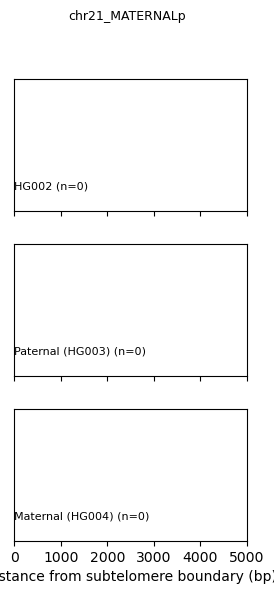

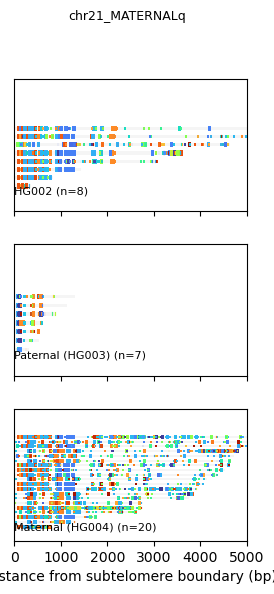

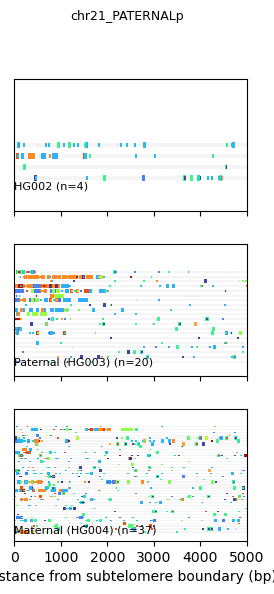

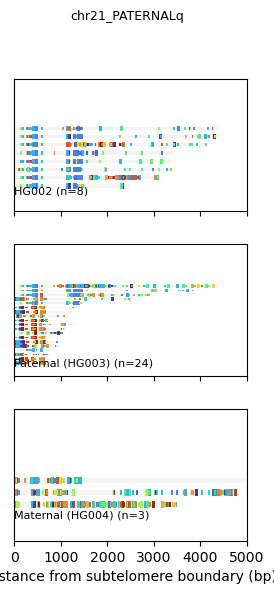

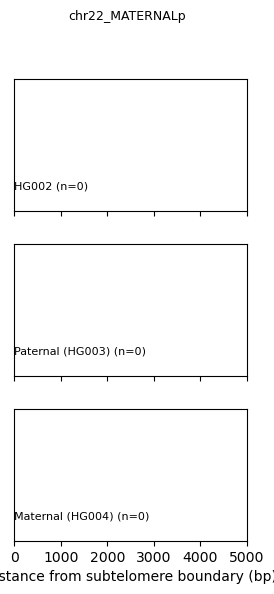

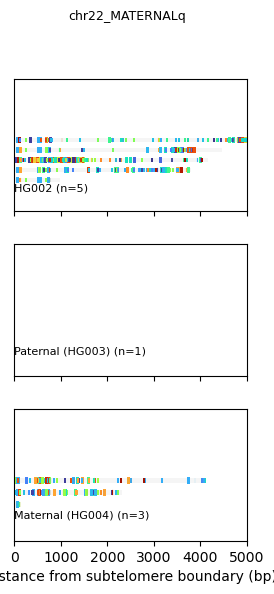

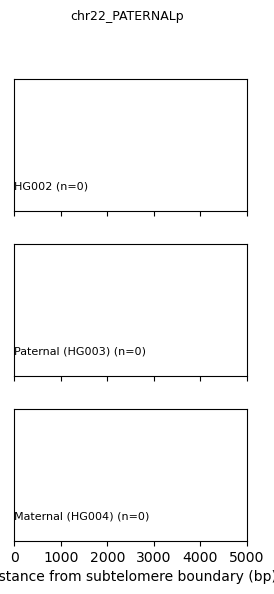

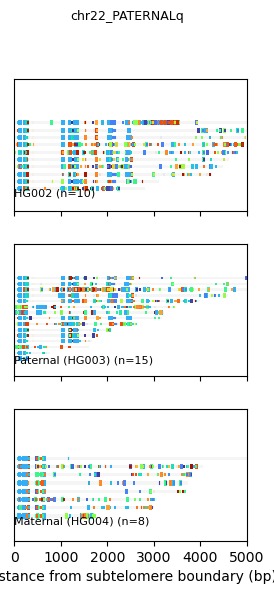

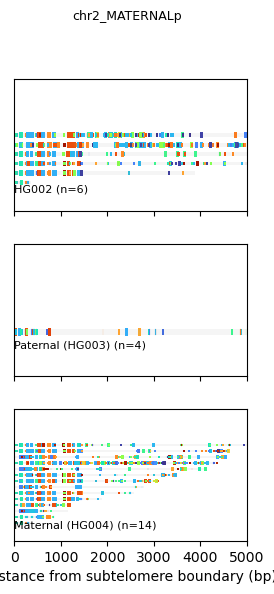

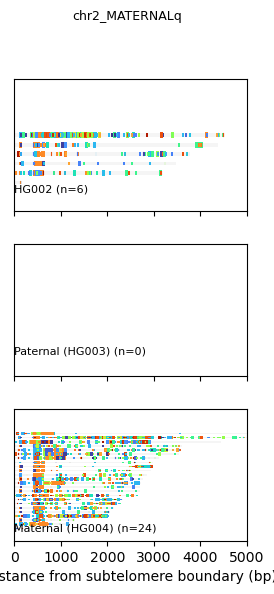

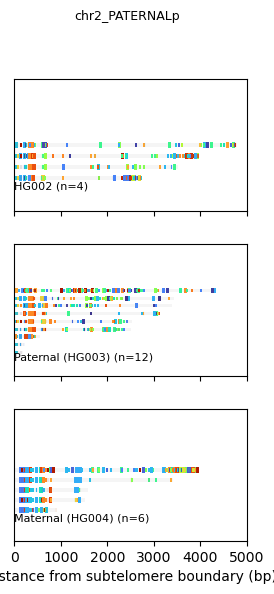

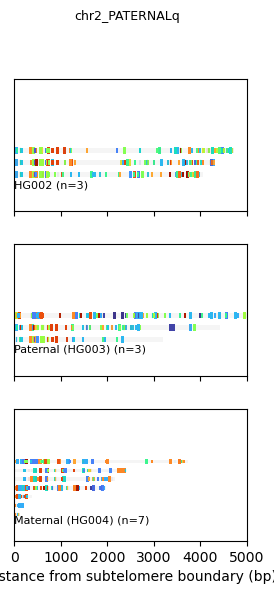

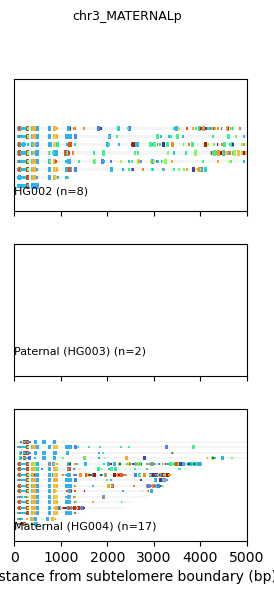

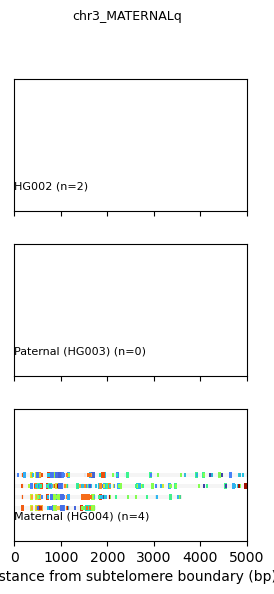

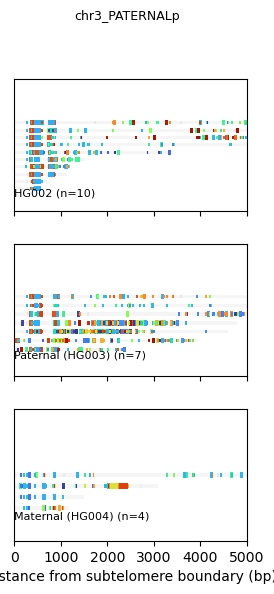

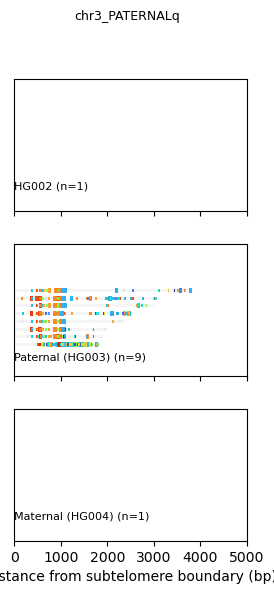

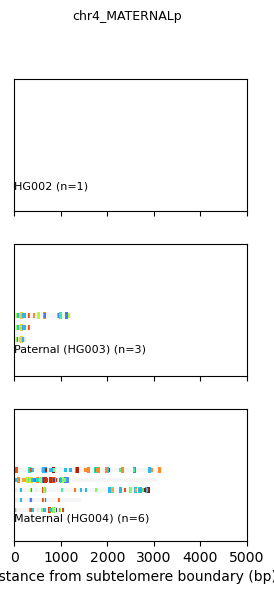

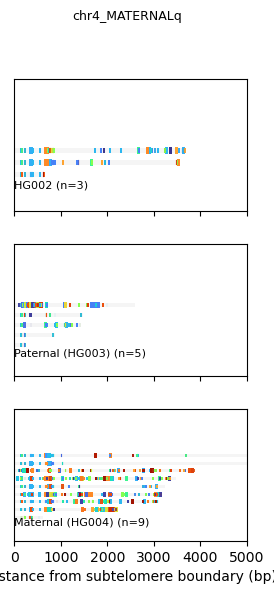

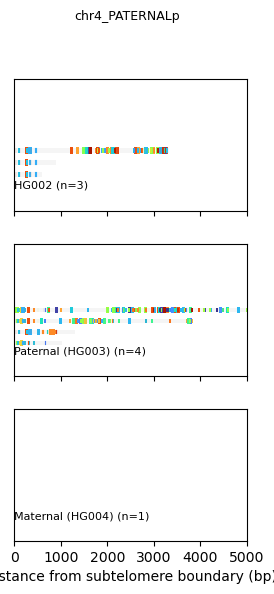

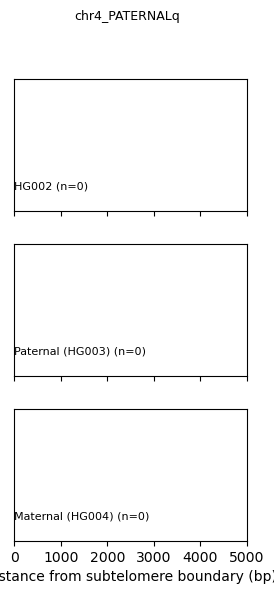

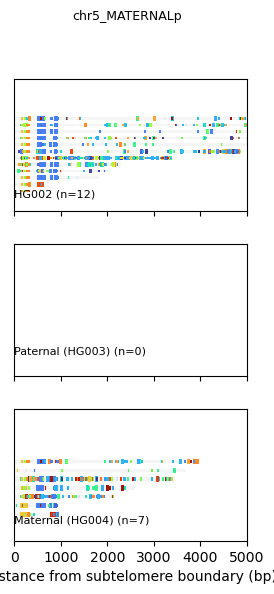

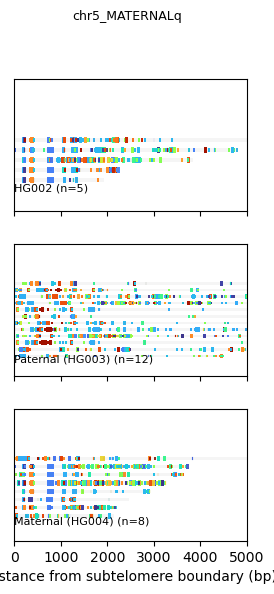

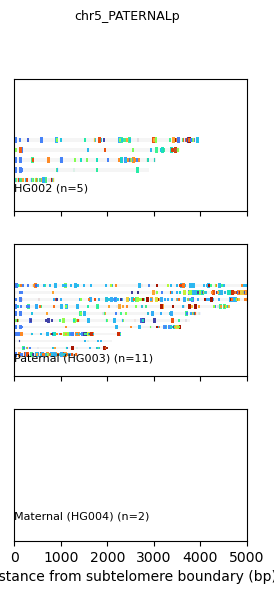

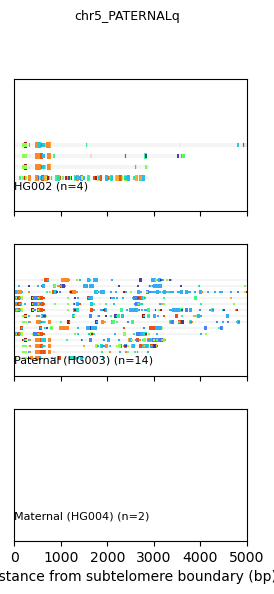

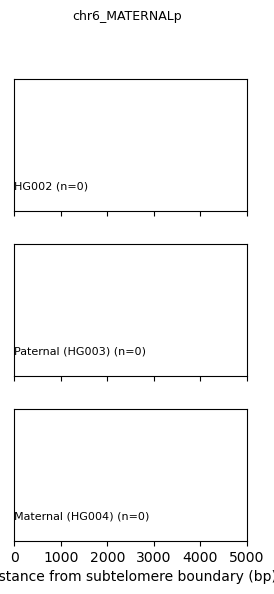

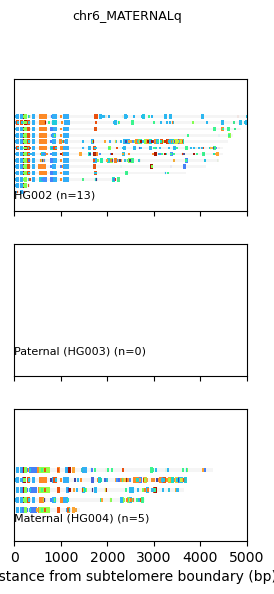

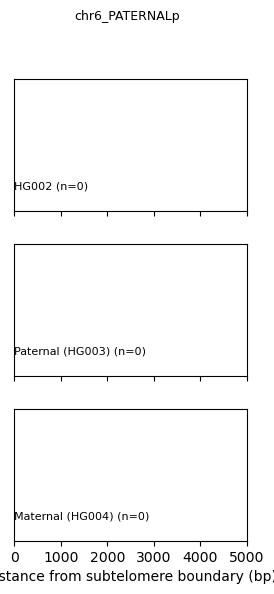

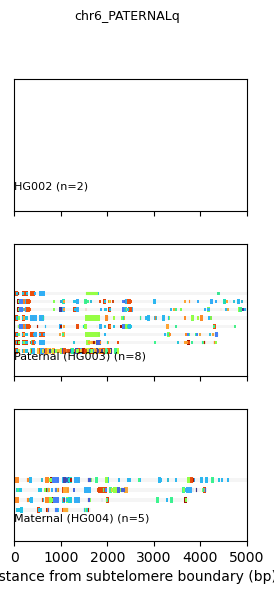

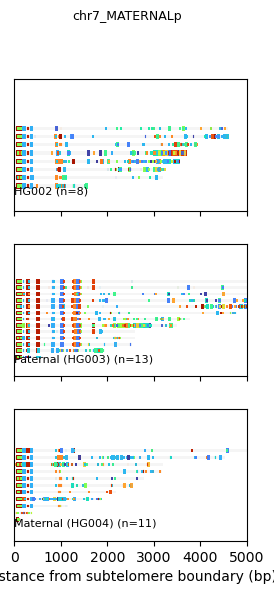

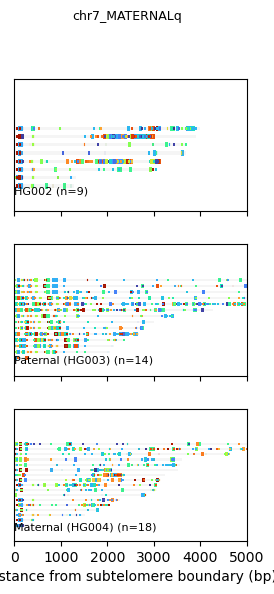

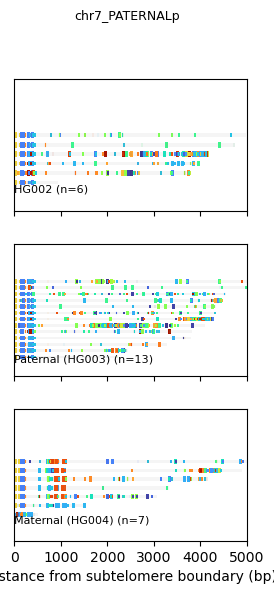

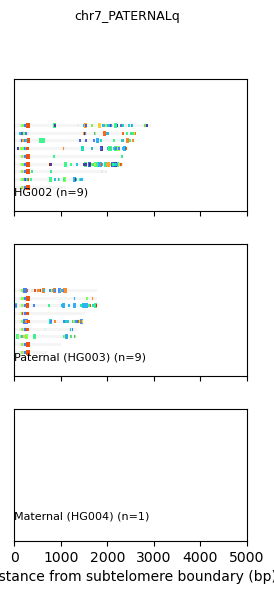

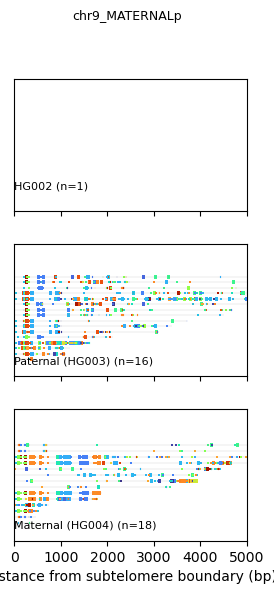

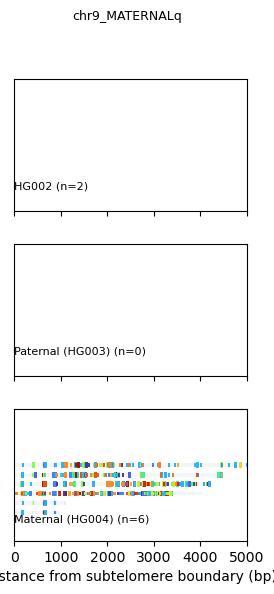

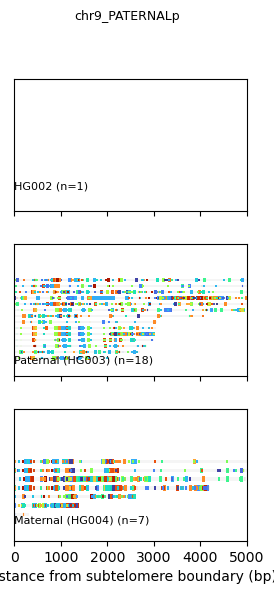

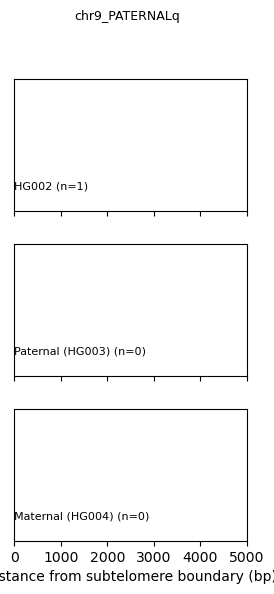

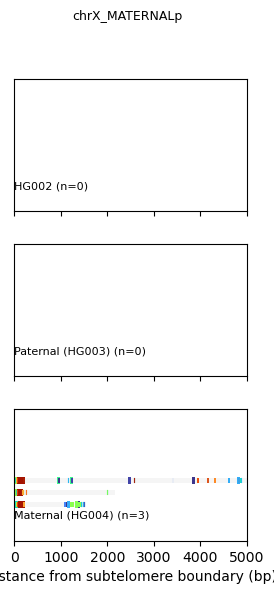

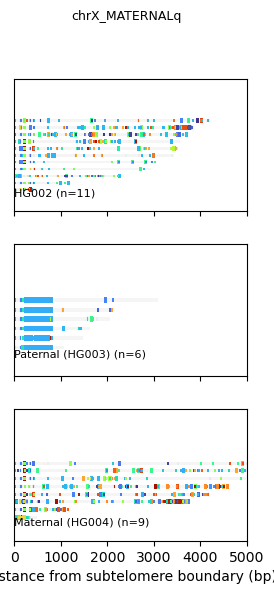

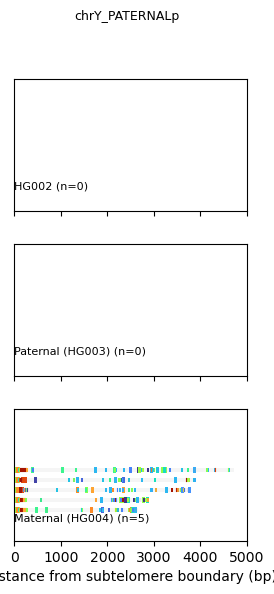

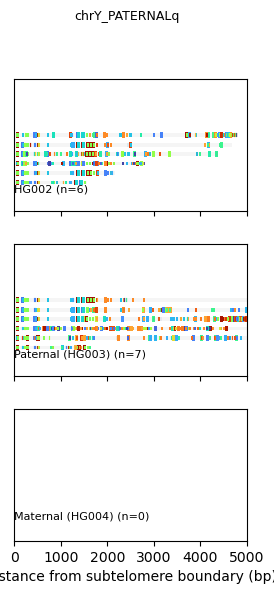

In [6]:
for chrom in np.unique(pedigree_tsvs['HG002'].chrom):
    for end in ['p','q']: 
        plotTVRs_three_samples_one_chrom(
            pedigree_tsvs,
            chrom + end,
            cmgr=cmgr,
            dist_bp=5_000,
            figsize=(3, 6),min_tvr_size=6,out_name = None
                )    